In [1]:
import numpy as np
import cv2
import os
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing import image
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
face_cascade = cv2.CascadeClassifier('../Data/haarcascade_frontalface_default.xml')

In [3]:
img_height, img_width = 48, 48

def load_dataset(train_dir, test_dir):
    def load_images(directory):
        images = []
        labels = []
        expressions = ['anger', 'fear', 'happy', 'neutral', 'sadness', 'surprise']
        for label, expression in enumerate(expressions):
            expression_folder = os.path.join(directory, expression)
            if not os.path.exists(expression_folder):
                continue
            for filename in os.listdir(expression_folder):
                img_path = os.path.join(expression_folder, filename)
                img = cv2.imread(img_path)
                gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

                faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))

                if len(faces) == 0:
                    continue

                x, y, w, h = faces[0]

                face_img = img[y:y+h, x:x+w]
                face_img = cv2.resize(face_img, (img_height, img_width))
                face_img = cv2.cvtColor(face_img, cv2.COLOR_BGR2GRAY)
                face_img = np.expand_dims(face_img, axis=-1)

                images.append(face_img)
                labels.append(label)

        images = np.array(images, dtype="float32") / 255.0
        labels = np.array(labels)
        return images, labels

    X_train, y_train = load_images(train_dir)
    X_test, y_test = load_images(test_dir)

    return X_train, y_train, X_test, y_test

In [4]:
train_dir = '../Data/CK+_Updated/train'
test_dir = '../Data/CK+_Updated/test'

X_train, y_train, X_test, y_test = load_dataset(train_dir, test_dir)

print('Training data shape: ', X_train.shape)
print('Test data shape: ', X_test.shape)

Training data shape:  (228, 48, 48, 1)
Test data shape:  (97, 48, 48, 1)


In [5]:
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(img_height, img_width, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(6, activation='softmax'),
])

C:\Users\sarah\source\repos\UCLan_ArtificialIntelligence\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test))

loss, accuracy = model.evaluate(X_test, y_test)
print(f'Test loss: {loss*100:.2f}%; Test accuracy: {accuracy*100:.2f}%')

model.save('./face_expression_model.h5')

Epoch 1/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - accuracy: 0.2281 - loss: 1.7319 - val_accuracy: 0.2371 - val_loss: 1.6967
Epoch 2/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.1974 - loss: 1.7376 - val_accuracy: 0.2474 - val_loss: 1.7083
Epoch 3/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.2675 - loss: 1.7408 - val_accuracy: 0.2474 - val_loss: 1.6956
Epoch 4/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.2588 - loss: 1.7173 - val_accuracy: 0.2474 - val_loss: 1.7143
Epoch 5/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.2588 - loss: 1.7082 - val_accuracy: 0.2577 - val_loss: 1.6795
Epoch 6/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.2456 - loss: 1.7075 - val_accuracy: 0.2474 - val_loss: 1.6791
Epoch 7/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.2412 - loss: 1.6999 - val_accuracy: 0.3918 - val_loss: 1.6692
Epoch 8/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.2632 - loss: 1.6881 - val_accuracy: 0.4124 - val_loss: 1.6604


Test loss: 72.68%; Test accuracy: 76.29%


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


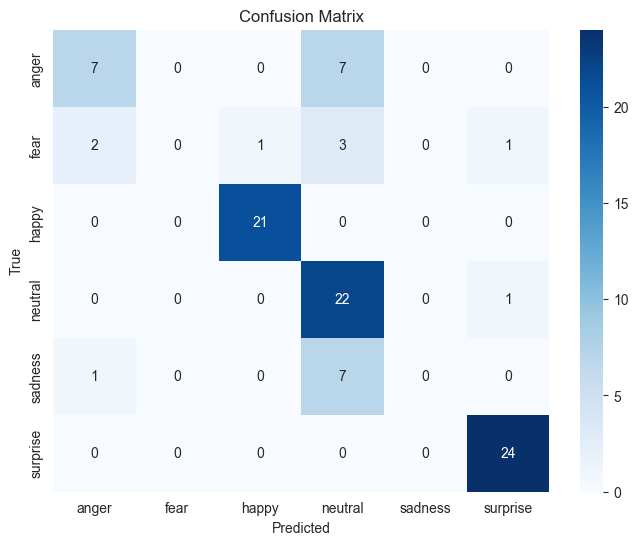

In [7]:
y_pred = model.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize = (8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['anger', 'fear', 'happy', 'neutral', 'sadness', 'surprise'], yticklabels=['anger', 'fear', 'happy', 'neutral', 'sadness', 'surprise'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
# Load the trained model
model = tf.keras.models.load_model('./face_expression_model.h5')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step


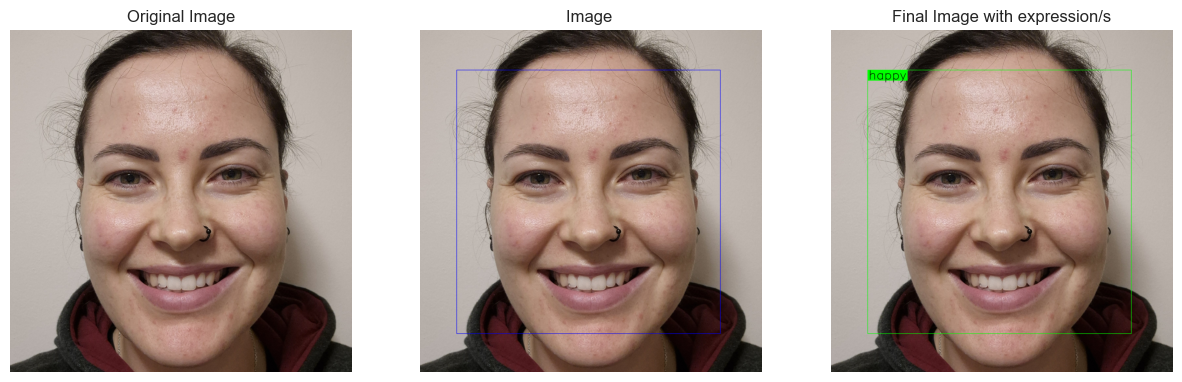

In [12]:
# Set image dimensions
img_height, img_width = 48, 48

# Dictionary of expression labels
expressions = ['anger', 'fear', 'happy', 'neutral', 'sadness', 'surprise']

# Load OpenCV's Haar cascade for face detection
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

# Function to preprocess the face for prediction
def preprocess_face(face):
    face_resized = cv2.resize(face, (img_height, img_width))  # Resize
    face_resized = np.expand_dims(face_resized, axis=-1)  # Add channel dimension
    face_resized = np.expand_dims(face_resized, axis=0)  # Add batch dimension
    face_resized = face_resized.astype("float32") / 255.0  # Normalize
    return face_resized

# Path to the test image
img_path = '../Data/assignment/CK_dataset/happy/20251201_195833.jpg'
#img_path = '../Data/assignment/CK_dataset/neutral/20251201_200909.jpg'
#img_path = '/content/drive/My Drive/FER-testingimages/test.png'
#img_path = '/content/drive/My Drive/FER-testingimages/test-2.png'
#img_path = '/content/drive/My Drive/FER-testingimages/test.png'

# Read the original image
original_img = cv2.imread(img_path)
gray_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2GRAY)  # Convert to grayscale

# Detect faces in the image
faces = face_cascade.detectMultiScale(gray_img, scaleFactor=1.3, minNeighbors=5)

# Create copies of the image to draw bounding boxes
face_detected_img = original_img.copy()
final_img = original_img.copy()

# Iterate through detected faces
for (x, y, w, h) in faces:
    face = gray_img[y:y+h, x:x+w]  # Extract face ROI
    processed_face = preprocess_face(face)  # Preprocess the face for the model

    # Get prediction
    prediction = model.predict(processed_face)
    predicted_class = np.argmax(prediction, axis=1)
    predicted_emotion = expressions[predicted_class[0]]

    # Draw bounding box on face detection image
    cv2.rectangle(face_detected_img, (x, y), (x + w, y + h), (255, 0, 0), 2)

    # Draw bounding box on final image
    cv2.rectangle(final_img, (x, y), (x + w, y + h), (0, 255, 0), 2)

    # Create a filled rectangle behind the text
    label_bg_color = (0, 255, 0)  # Green background
    text_color = (0, 0, 0)  # White text
    font = cv2.FONT_HERSHEY_SIMPLEX
    font_scale = 2.5
    font_thickness = 2

    # Get text size to draw background rectangle
    (text_width, text_height), _ = cv2.getTextSize(predicted_emotion, font, font_scale, font_thickness)
    label_x1, label_y1 = x, y  # Top-left corner of the bounding box
    label_x2, label_y2 = x + text_width + 10, y + text_height + 10  # Bottom-right corner for background

    # Draw the background rectangle
    cv2.rectangle(final_img, (label_x1, label_y1), (label_x2, label_y2), label_bg_color, -1)

    # Put the emotion label text inside the bounding box
    cv2.putText(final_img, predicted_emotion, (x + 5, y + text_height + 2), font,
                font_scale, text_color, font_thickness, cv2.LINE_AA)

# Convert BGR images to RGB for Matplotlib display
original_img_rgb = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)
face_detected_img_rgb = cv2.cvtColor(face_detected_img, cv2.COLOR_BGR2RGB)
final_img_rgb = cv2.cvtColor(final_img, cv2.COLOR_BGR2RGB)

# Display all three images using matplotlib
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(original_img_rgb)
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(face_detected_img_rgb)
axes[1].set_title("Image ")
axes[1].axis("off")

axes[2].imshow(final_img_rgb)
axes[2].set_title("Final Image with expression/s", )
axes[2].axis("off")

plt.show()  # Show the images side by side